# Notebook 13: Tree-Based Classifiers — Baseline (Frozen Embeddings)

## Purpose
Evaluate four tree-based ensemble classifiers on frozen `all-MiniLM-L6-v2`
embeddings as an alternative to the MLP head explored in Notebooks 09-13.
Tree-based classifiers require no gradient-based training, no batch scheduling,
and no early stopping — they fit directly on the full embedding matrix.

## Classifiers
| Classifier | Imbalance Strategy |
|---|---|
| Random Forest (RF) | `class_weight='balanced'` |
| Extra Trees (ET) | `class_weight='balanced'` |
| XGBoost (XGB) | `scale_pos_weight=102` |
| LightGBM (LGBM) | `is_unbalance=True` |

## Baseline
Real training data only — no augmentation. Direct comparison to:
- LR baseline: F1=0.152
- MLP-1 baseline: F1=0.270
- MLP-2 baseline: F1=0.207

## Evaluation
- Threshold optimized on calibration set — identical to Notebooks 09-12
- Metrics: Precision, Recall, F1 vs MLP baselines
- DET curves: all four tree classifiers overlaid

In [2]:
# -----------------------------------------------
# Imports and setup
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

os.chdir("..")

# -----------------------------------------------
# Load frozen embeddings and splits
# -----------------------------------------------
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# Imbalance ratio for XGBoost scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = n_neg / n_pos
print(f"\nImbalance ratio: {SCALE_POS_WEIGHT:.1f}:1")

# -----------------------------------------------
# Load MLP baseline metrics for comparison
# -----------------------------------------------
with open("data/results/metrics_09_baseline.json") as f:
    mlp_baseline = json.load(f)

print("\nMLP baselines (Notebook 09):")
for name, m in mlp_baseline.items():
    print(f"  {name}: F1={m['f1']:.3f} | "
          f"P={m['precision']:.3f} | R={m['recall']:.3f}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

Imbalance ratio: 102.1:1

MLP baselines (Notebook 09):
  LR: F1=0.152 | P=0.085 | R=0.729
  MLP-1: F1=0.270 | P=0.190 | R=0.464
  MLP-2: F1=0.207 | P=0.134 | R=0.448


In [3]:
# -----------------------------------------------
# Threshold optimization utility
# Identical to Notebooks 09-12
# -----------------------------------------------
def optimal_threshold_f1(
    y_true, y_scores,
    thresholds=np.arange(0.01, 0.99, 0.01),
) -> tuple[float, float]:
    """
    Find threshold maximizing F1 on provided set.
    Always called on calibration set — never test set.
    Note: range extended to 0.99 for tree classifiers
    whose score distributions differ from MLP softmax.
    """
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


# -----------------------------------------------
# Classifier definitions
# Four tree-based classifiers with imbalance handling
# n_estimators=300 balances quality and training time
# on CPU — can increase on Colab with GPU/more RAM
# -----------------------------------------------
def get_classifiers(scale_pos_weight: float, seed: int = SEED) -> dict:
    return {
        'RF': RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            max_features='sqrt',
            n_jobs=-1,
            random_state=seed,
        ),
        'ET': ExtraTreesClassifier(
            n_estimators=300,
            class_weight='balanced',
            max_features='sqrt',
            n_jobs=-1,
            random_state=seed,
        ),
        'XGB': XGBClassifier(
            n_estimators=300,
            scale_pos_weight=scale_pos_weight,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=seed,
            n_jobs=-1,
        ),
        'LGBM': LGBMClassifier(
            n_estimators=300,
            is_unbalance=True,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        ),
    }


# -----------------------------------------------
# Evaluation utility
# Fits classifier, optimizes threshold on cal set,
# evaluates on test set — same pipeline as MLP notebooks
# -----------------------------------------------
def evaluate_classifier(
    clf,
    X_train, y_train,
    X_cal, y_cal,
    X_test, y_test,
    name: str = "Classifier",
) -> dict:
    print(f"\nTraining {name}...")
    clf.fit(X_train, y_train)

    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))

    return {
        'name':        name,
        'clf':         clf,
        'threshold':   t,
        'cal_f1':      cal_f1,
        'test_scores': test_scores,
        'y_pred':      y_pred,
        'precision':   prec,
        'recall':      rec,
        'f1':          f1,
    }

print("Classifier definitions and utilities ready.")

Classifier definitions and utilities ready.


In [4]:
# -----------------------------------------------
# Train all four tree-based classifiers
# No epochs, no early stopping — single fit call
# Threshold optimized on calibration set
# -----------------------------------------------
classifiers = get_classifiers(scale_pos_weight=SCALE_POS_WEIGHT)
results = {}

for name, clf in classifiers.items():
    results[name] = evaluate_classifier(
        clf,
        X_train, y_train,
        X_cal, y_cal,
        X_test, y_test,
        name=name,
    )


Training RF...
=== RF (threshold=0.06) ===
              precision    recall  f1-score   support

           0      0.991     0.992     0.991     19669
           1      0.117     0.115     0.116       192

    accuracy                          0.983     19861
   macro avg      0.554     0.553     0.554     19861
weighted avg      0.983     0.983     0.983     19861


Training ET...
=== ET (threshold=0.05) ===
              precision    recall  f1-score   support

           0      0.991     0.995     0.993     19669
           1      0.137     0.089     0.108       192

    accuracy                          0.986     19861
   macro avg      0.564     0.542     0.550     19861
weighted avg      0.983     0.986     0.984     19861


Training XGB...
=== XGB (threshold=0.64) ===
              precision    recall  f1-score   support

           0      0.991     0.997     0.994     19669
           1      0.253     0.099     0.142       192

    accuracy                          0.988     

Condition            Classifier  Threshold        P        R       F1
----------------------------------------------------------------------
MLP Baseline         LR               0.69    0.085    0.729    0.152
MLP Baseline         MLP-1            0.69    0.190    0.464    0.270
MLP Baseline         MLP-2            0.69    0.134    0.448    0.207
----------------------------------------------------------------------
Tree Baseline        RF               0.06    0.117    0.115    0.116
Tree Baseline        ET               0.05    0.137    0.089    0.108
Tree Baseline        XGB              0.64    0.253    0.099    0.142
Tree Baseline        LGBM             0.61    0.167    0.109    0.132


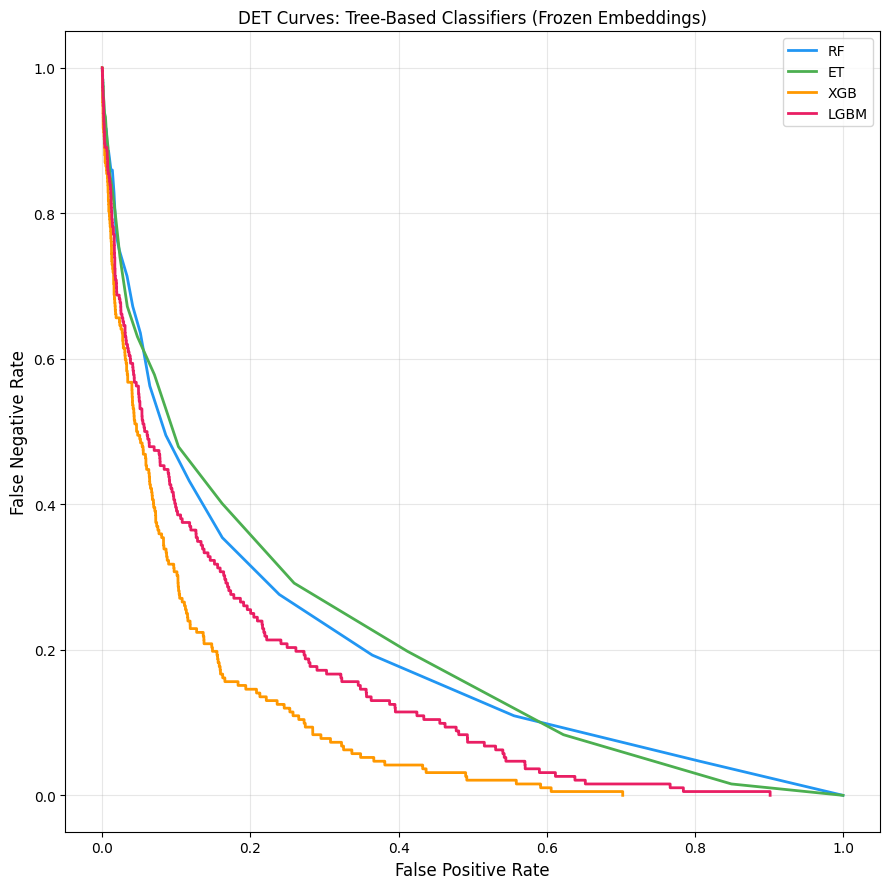

DET curves saved.
Metrics saved to data/results/metrics_13_tree_baseline.json

Notebook 13 complete — tree baseline is a negative result.
Augmentation experiments for tree classifiers not warranted.


In [5]:
# -----------------------------------------------
# Summary table
# -----------------------------------------------
print("=" * 70)
print(f"{'Condition':<20} {'Classifier':<10} {'Threshold':>10} "
      f"{'P':>8} {'R':>8} {'F1':>8}")
print("-" * 70)

# MLP baselines for reference
for clf_name, m in mlp_baseline.items():
    print(f"{'MLP Baseline':<20} {clf_name:<10} {m['threshold']:>10.2f} "
          f"{m['precision']:>8.3f} {m['recall']:>8.3f} {m['f1']:>8.3f}")

print("-" * 70)

# Tree baseline results
for name, r in results.items():
    print(f"{'Tree Baseline':<20} {name:<10} {r['threshold']:>10.2f} "
          f"{r['precision']:>8.3f} {r['recall']:>8.3f} {r['f1']:>8.3f}")

print("=" * 70)

# -----------------------------------------------
# DET curves
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

clf_colors = {
    'RF':   '#2196F3',
    'ET':   '#4CAF50',
    'XGB':  '#FF9800',
    'LGBM': '#E91E63',
}

for name, r in results.items():
    fpr, fnr, _ = det_curve(y_test, r['test_scores'])
    ax.plot(fpr, fnr, color=clf_colors[name],
            linewidth=2, label=name)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title("DET Curves: Tree-Based Classifiers (Frozen Embeddings)",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/results/det_curves_13_tree_baseline.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

# -----------------------------------------------
# Save metrics
# -----------------------------------------------
os.makedirs("data/results", exist_ok=True)

metrics_13 = {
    name: {
        'precision': round(r['precision'], 4),
        'recall':    round(r['recall'], 4),
        'f1':        round(r['f1'], 4),
        'threshold': round(r['threshold'], 4),
        'cal_f1':    round(r['cal_f1'], 4),
    }
    for name, r in results.items()
}

with open("data/results/metrics_13_tree_baseline.json", "w") as f:
    json.dump(metrics_13, f, indent=2)
print("Metrics saved to data/results/metrics_13_tree_baseline.json")
print("\nNotebook 13 complete — tree baseline is a negative result.")
print("Augmentation experiments for tree classifiers not warranted.")

In [6]:
results['XGB_shallow'] = evaluate_classifier(
    XGBClassifier(n_estimators=300, scale_pos_weight=SCALE_POS_WEIGHT,
                  learning_rate=0.05, max_depth=3, subsample=0.8,
                  colsample_bytree=0.8, eval_metric='logloss',
                  random_state=SEED, n_jobs=-1),
    X_train, y_train, X_cal, y_cal, X_test, y_test,
    name="XGB_shallow",
)


Training XGB_shallow...
=== XGB_shallow (threshold=0.85) ===
              precision    recall  f1-score   support

           0      0.991     0.994     0.992     19669
           1      0.136     0.104     0.118       192

    accuracy                          0.985     19861
   macro avg      0.564     0.549     0.555     19861
weighted avg      0.983     0.985     0.984     19861

